This notebook contains training a neural network for additional current with which we try to match the recording from a single-compartment PASSIVE model to the multi-compartment one.

Here we use the normalized voltage and the us as input to the neural network (time is not included!). We define u in a differential equation.

In [1]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)



import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax

import equinox as eqx
import flax.nnx as nnx

In [2]:
t_max = 200.0
setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"
cut = 0



# Define target
from voltage_fitting.build_simulator import (
    setup_passive_simulator,
    get_experimental_data,
    build_passive_cell,
    set_setup,
)
t, x_o, i_amp = get_experimental_data(setup, cut, t_max)


all_setup = set_setup(setup)
cell = build_passive_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"])

simulate_multi = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)

v_multi = simulate_multi()

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [3]:
#Define the cell
from voltage_fitting.single_build_simulator import (
    setup_passive_simulator,
    setup_passive_simulator_step,
    build_passive_cell,
    set_setup,
)

all_setup = set_setup(setup)
cell = build_passive_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

simulate_single = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)

v_single = simulate_single(x_o)[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [4]:
# Define the networks
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_multi)) / (jnp.max(v_multi) - jnp.min(v_multi)) - 1
    

class SimpleNeuralNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8):
        self.linear1 = nnx.Linear(u_dimension + 1, 32, rngs=rngs)
        #self.norm1 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear2 = nnx.Linear(32, 16, rngs=rngs)
        #self.norm2 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear3 = nnx.Linear(16, u_dimension, rngs=rngs)

    def __call__(self, inputs):
        x = self.linear1(inputs)
        x = jax.nn.relu(x)

        x = self.linear2(x)
        x = jax.nn.relu(x)
        return self.linear3(x)

class ReadoutNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8):
        self.linear1 = nnx.Linear(u_dimension, 32, rngs=rngs)
        self.linear2 = nnx.Linear(32, 1, rngs=rngs)

    def __call__(self, u):
        u = self.linear1(u)
        u = jax.nn.relu(u)
        return self.linear2(u)
    
class CorrectionModel(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8):
        self.neural_net = SimpleNeuralNet(rngs=rngs, u_dimension = u_dimension)
        self.readout_net = ReadoutNet(rngs=rngs, u_dimension = u_dimension)

    def __call__(self, u, v):
        u_new = self.neural_net(jnp.stack([u, v]))
        return self.readout_net(u_new)

In [5]:
dt = 0.025

def simulate_full_trace(neural_net, readout_net, initial_state, step_fn, current, time_vec, u_init, added_curr_std, u_time_constant):
    def cond_fn(carry):
        t, _, _, _ = carry
        return t < len(time_vec)

    def body_fn(carry):
        t, state, u, recs_adds = carry

        voltage = state["v"].squeeze()
        voltage_normalized = normalize_voltage(voltage)

        # Here only the normalized voltage and u are in the input
        inputs = jnp.concatenate([jnp.expand_dims(voltage_normalized, 0), u], axis=0)

        u_new = u + dt*neural_net(inputs) / u_time_constant #0.02 #0.0008
        add_current = readout_net(u_new).squeeze()


        total_current = current[t] + add_current * added_curr_std #/300 #10
        state, rec = step_fn(state, total_current)

        rec_voltage = rec[0]

        new_us, new_recs, new_adds = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)
        new_us = new_us.at[t].set(u_new)

        return (t + 1, state, u_new.squeeze(), (new_us, new_recs, new_adds))

    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (us, recs, adds))

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, _, (us, recs, adds) = final_carry

    return recs, adds, us

In [6]:
def loss_fn(model, initial_state, step_fn, current, time_vec, u_init, v_multi, added_curr_std, u_time_constant, reg_strength=0.0):
    
    preds, additional_currents, us = simulate_full_trace(
        model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, added_curr_std, u_time_constant
    )

    preds = preds.squeeze()
    v_multi = v_multi.squeeze()

    sse_loss = jnp.sum((preds - v_multi) ** 2)
    reg_loss = reg_strength * jnp.sum(jnp.abs(additional_currents))

    total_loss = sse_loss + reg_loss
    return total_loss

In [7]:
rngs = nnx.Rngs(1)

u_dimension = 8
np.random.seed(42)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
model = CorrectionModel(rngs = rngs, u_dimension=u_dimension)


all_setup = set_setup(setup)
cell = build_passive_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
initial_state, step_fn, current, time_vec = setup_passive_simulator_step(cell, t_max, all_setup["v_init"], i_amp)

added_curr_std = 1.0/300.0
u_time_constant = 100


initial_lr = 30e-3  #2e-1 for lbfgs?
decay_factor = 0.99 
transition_steps = 1  # decay after every epoch
#decay_until = 400  # after x epochs, stop decaying
decay_start = 600
decay_end = 750

# Normal exponential decay schedule
raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)

# Wrapped schedule that stops decaying after decay_until
# def clipped_schedule(step):
#     clipped_step = jnp.minimum(step, decay_until)
#     return raw_schedule(clipped_step)

def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

optimizer = optax.adam(learning_rate=custom_schedule)

# Other optimizers tried:
# optimizer = optax.sgd(learning_rate=clipped_schedule, momentum = 0.7)
# optimizer = optax.chain(
#     optax.clip_by_global_norm(1e6),  # Clip gradients
#     optax.sgd(learning_rate=clipped_schedule, momentum=0.5)
# )

# optimizer = optax.chain(
#     optax.scale_by_lbfgs(memory_size = 8), #6
#     optax.scale(-initial_lr),
# )

optimizer_state = nnx.Optimizer(model, optimizer)


def simulation_loss_fn(model):
        loss = loss_fn(model, initial_state, step_fn, current, time_vec, u_init, v_multi, added_curr_std, u_time_constant)
        return loss


num_epochs = 1000
losses = []

grad_fn = nnx.jit(nnx.value_and_grad(simulation_loss_fn))

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [8]:
for epoch in range(num_epochs):

    # if epoch == 370: #370
    #     optimizer = optax.chain(
    #         optax.scale_by_lbfgs(memory_size = 8), #8
    #         optax.scale(-0.2e-1), #0.3
    #     )
    #     optimizer_state = nnx.Optimizer(optimizer_state.model, optimizer)
    

    loss, grads = grad_fn(optimizer_state.model)
    optimizer_state.update(grads)


    # inter_ts, inter_us, inter_preds, inter_additional_currents = simulate_full_trace(
    # model.neural_net,
    # model.readout_net,
    # initial_state,
    # step_fn,
    # current,
    # time_vec,
    # u_init
    # )
    

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")
        # print(f"Min added current: {jnp.min(inter_additional_currents)}, max added current: {jnp.max(inter_additional_currents)}")
        # print(f"Min u: {jnp.min(inter_us)}, max u: {jnp.max(inter_us)}")
        # print(f"Min tnn: {jnp.min(inter_ts)}, max tnn: {jnp.max(inter_ts)}")
        # print("")

Epoch 0, Loss: 1366.872934
Epoch 10, Loss: 996.464093
Epoch 20, Loss: 843.077244
Epoch 30, Loss: 838.329689
Epoch 40, Loss: 790.966624
Epoch 50, Loss: 711.861236
Epoch 60, Loss: 580.432913
Epoch 70, Loss: 510.210875
Epoch 80, Loss: 438.494867
Epoch 90, Loss: 343.723451
Epoch 100, Loss: 298.159315
Epoch 110, Loss: 280.317023
Epoch 120, Loss: 283.735148
Epoch 130, Loss: 217.911613
Epoch 140, Loss: 179.044065
Epoch 150, Loss: 149.038827
Epoch 160, Loss: 128.322546
Epoch 170, Loss: 148.395322
Epoch 180, Loss: 299.135147
Epoch 190, Loss: 203.778757
Epoch 200, Loss: 152.861712
Epoch 210, Loss: 134.892558
Epoch 220, Loss: 117.426797
Epoch 230, Loss: 105.340463
Epoch 240, Loss: 93.791776
Epoch 250, Loss: 85.454513
Epoch 260, Loss: 78.186215
Epoch 270, Loss: 72.128809
Epoch 280, Loss: 66.930085
Epoch 290, Loss: 78.959330
Epoch 300, Loss: 202.460036
Epoch 310, Loss: 77.686709
Epoch 320, Loss: 85.535882
Epoch 330, Loss: 75.255305
Epoch 340, Loss: 68.303650
Epoch 350, Loss: 62.350006
Epoch 360, Lo

In [9]:
final_preds, final_additional_currents, final_us = simulate_full_trace(
    model.neural_net,
    model.readout_net,
    initial_state,
    step_fn,
    current,
    time_vec,
    u_init,
    added_curr_std,
    u_time_constant
)


final_sse_loss = jnp.sum((final_preds.squeeze() - v_multi.squeeze())**2)
final_reg_loss = jnp.sum(final_additional_currents)

In [10]:
print("Final SSE loss: ", final_sse_loss, ", Final regulation loss: ", final_reg_loss)

Final SSE loss:  17.554966863999166 , Final regulation loss:  2298.1235614838665


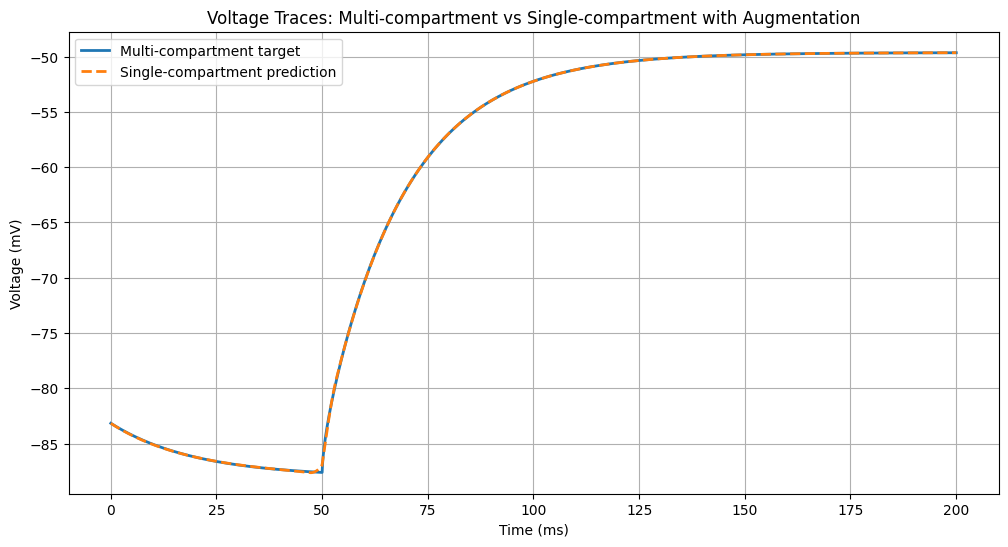

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec, v_multi[0], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

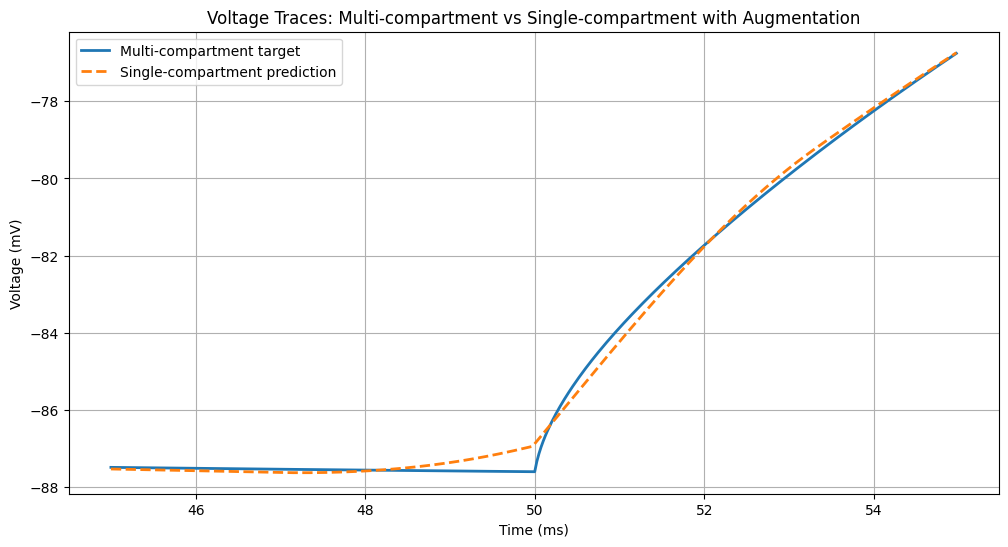

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec[1800:2200], v_multi[0][1800:2200], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec[1800:2200], final_preds[1800:2200], label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

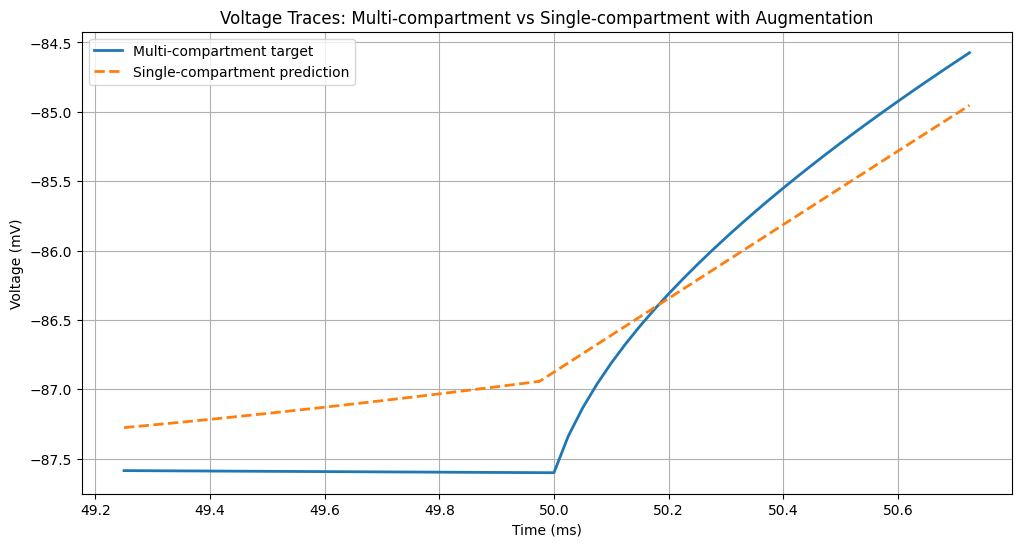

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec[1970:2030], v_multi[0][1970:2030], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec[1970:2030], final_preds[1970:2030], label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

Text(0.5, 1.0, 'Additional current (mV)')

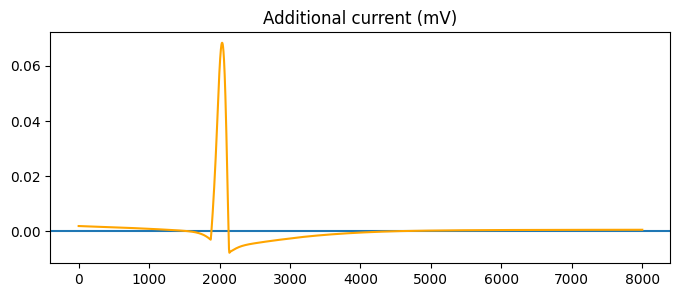

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
_ = ax.axhline(0.0)
_ = ax.plot(final_additional_currents * added_curr_std, color = "orange")
ax.set_title("Additional current (mV)")

In [15]:
np.save("../results/no_t_final_preds.npy", final_preds)
np.save("../results/no_t_final_additional_currents.npy", final_additional_currents)
np.save("../results/no_t_losses.npy", losses)

Text(0.5, 1.0, 'Hidden state (u) dynamics after training, time_constant = 100')

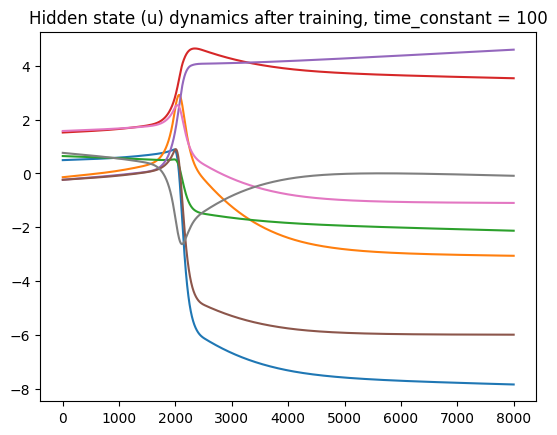

In [17]:
#u dynamics after training, time_constant = 100
plt.plot(final_us)
plt.title("Hidden state (u) dynamics after training, time_constant = 100")